# Courtship song — paper-ready figures

Per paired courtship bout this notebook answers four questions:

1. Which fly is the male? (the singer — Drosophila courtship song is male-produced)
2. What song types is he performing? (pulse / sine / waggle / quiet)
3. What are his walking patterns during singing? (forward speed, turn rate, walking vs stopped)
4. How does his center-of-mass height change across song types?

Data source: the post-rescue relinked h5 produced by `rescue_identity_relink_inplace.py`.
All reusable logic lives in `utils/song_analysis.py`, `utils/sex_id.py`, `utils/locomotion.py`.
The sandbox notebook `Courtship_Song_Analysis.ipynb` is untouched; this is a clean sibling.


In [ ]:
# --- Setup: imports + matplotlib style + output dir ---
from __future__ import annotations

import os, sys, pickle, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Project imports (notebook runs from the repo root OR from notebooks/)
REPO_ROOT = Path('.').resolve()
if not (REPO_ROOT / 'utils').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.courtship_loader import (
    load_courtship_h5, pair_bouts, get_fields, analyze_pair, analyze_all_pairs,
)
from utils.pair_validity import PairValidityConfig
from utils.song_analysis import SongAnalysisConfig
from utils.sex_id import SexIdConfig
from utils.locomotion import LocomotionConfig
from utils.locomotion import walking_fraction

# Paper-ready matplotlib defaults: Type-1 / sans-serif / clean spines
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.transparent': False,
})
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Colors shared across figures
SONG_COLORS = {
    'pulse':  '#d62728',  # red
    'sine':   '#1f77b4',  # blue
    'waggle': '#9467bd',  # purple
    'quiet':  '#bdbdbd',  # grey
}
# After the reorder in analyze_pair, slot 0 = male, slot 1 = female.
FLY_COLORS = {'fly0': '#ff7f0e', 'fly1': '#2ca02c'}  # male, female

FIG_DIR = REPO_ROOT / 'figures' / 'courtship'
FIG_DIR.mkdir(parents=True, exist_ok=True)

H5_PATH = Path('/data2/users/eabe/datasets/Johnson_lab/courtship/04092026_bouts_04112026/'
               'v1/'
               'ik_output_combined_v1_courtship_both.h5')

CACHE_PATH = FIG_DIR / 'per_bout_cache.pkl'

print(f'repo   : {REPO_ROOT}')
print(f'h5     : {H5_PATH}')
print(f'figures: {FIG_DIR}')


repo   : /home/eabe/Research/MyRepos/3d_tracking_dataset
h5     : /data2/users/eabe/datasets/Johnson_lab/courtship/04092026_bouts_04112026/v1/ik_output_combined_v1_courtship_both.h5
figures: /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship


In [ ]:
# --- Load the relinked h5 and pair fly0/fly1 bouts ---
# Each bout key in this h5 holds ONE fly's kp_data / xpos_egocentric / qpos.
# The pairing is consecutive (fly0, fly1) and validated by info['source_flies'].

print('loading h5 (slow — full file)...')
data, info, kp_names, bout_keys = load_courtship_h5(H5_PATH)

pairs = pair_bouts(bout_keys, info)
print(f'bouts: {len(bout_keys)}  pairs: {len(pairs)}  kp: {len(kp_names)}')
print(f'first 3 pairs: {pairs[:3]}')


loading h5 (slow — full file)...
bouts: 276  pairs: 138  kp: 50
first 3 pairs: [('bout_000', 'bout_001'), ('bout_002', 'bout_003'), ('bout_004', 'bout_005')]


In [ ]:
# --- Run the full per-pair analysis and cache to a pickle ---
# Set FORCE=True to invalidate the cache and re-run from scratch.
FORCE = True

song_cfg = SongAnalysisConfig()
sex_cfg  = SexIdConfig()
loc_cfg  = LocomotionConfig()
pair_cfg = PairValidityConfig()

results = analyze_all_pairs(
    data, pairs, kp_names,
    cache_path=CACHE_PATH,
    force=FORCE,
    song_cfg=song_cfg,
    sex_cfg=sex_cfg,
    loc_cfg=loc_cfg,
    pair_cfg=pair_cfg,
)

print(f'ok: {len(results)} pair results loaded')


  processed 25/138
  processed 50/138
  processed 75/138
  processed 100/138
  processed 125/138
cached 138 pair results -> /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/per_bout_cache.pkl
ok: 138 pair results loaded


In [ ]:
# --- Build a per-bout results dataframe for figures + CSV export ---
def _frac(labels, valid):
    labels = np.asarray(labels); valid = np.asarray(valid, dtype=bool)
    n = int(valid.sum())
    if n == 0:
        return {k: float('nan') for k in ('pulse', 'sine', 'waggle', 'quiet')}
    sel = labels[valid]
    return {k: float(np.mean(sel == k)) for k in ('pulse', 'sine', 'waggle', 'quiet')}

rows = []
for r in results:
    sex = r['sex']
    fr  = _frac(r['male_labels'], r['male_valid'])
    bs  = r['by_song']
    row = {
        'pair_idx':                   r['pair_idx'],
        # Post-swap keys: key0 is always the male's original bout, key1 the female's.
        'key0':                       r['key0'],
        'key1':                       r['key1'],
        'T':                          r['T'],
        'male_id':                    sex['male_id'],
        'female_id':                  sex['female_id'],
        'criterion':                  sex['criterion'],
        'confidence':                 sex['confidence'],
        'disagree_bodylen':           sex['disagree'],
        # Semantic (post-swap) song fractions. slot0=male, slot1=female.
        'song_fraction_male':         r['song0']['summary']['song_fraction'],
        'song_fraction_female':       r['song1']['summary']['song_fraction'],
        'body_length_male':           sex['body_length_male'],
        'body_length_female':         sex['body_length_female'],
        # Raw tracker-slot record for traceability + Figure 1.
        'tracker_male_id':            r['tracker_male_id'],
        'tracker_key0':               r['tracker_key0'],
        'tracker_key1':               r['tracker_key1'],
        'tracker_song_fraction_fly0': r['tracker_song_fraction_fly0'],
        'tracker_song_fraction_fly1': r['tracker_song_fraction_fly1'],
        'frac_pulse':                 fr['pulse'],
        'frac_sine':                  fr['sine'],
        'frac_waggle':                fr['waggle'],
        'frac_quiet':                 fr['quiet'],
        'walking_fraction':           walking_fraction(r['walking_state'][r['male_valid']]) if r['male_valid'].any() else float('nan'),
        'mean_com_z':                 float(np.nanmean(r['com_z'][r['male_valid']])) if r['male_valid'].any() else float('nan'),
        'mean_speed_bl':              float(np.nanmean(r['kin'].get('speed_bl', r['kin']['speed'])[r['male_valid']])) if r['male_valid'].any() else float('nan'),
    }
    # Song-conditioned aggregates
    for song in ('pulse', 'sine', 'waggle', 'quiet'):
        stats = bs.get(song, {})
        for m in ('speed_bl', 'forward_speed_bl', 'turn_rate', 'com_z'):
            row[f'{song}_{m}_mean'] = stats.get(m, {}).get('mean', float('nan'))
            row[f'{song}_{m}_n']    = stats.get(m, {}).get('n',    0)
    rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()


(138, 57)


,pair_idx,key0,key1,T,male_id,female_id,criterion,confidence,disagree_bodylen,song_fraction_male,song_fraction_female,body_length_male,body_length_female,tracker_male_id,tracker_key0,tracker_key1,tracker_song_fraction_fly0,tracker_song_fraction_fly1,frac_pulse,frac_sine,frac_waggle,frac_quiet,walking_fraction,mean_com_z,mean_speed_bl,pulse_speed_bl_mean,pulse_speed_bl_n,pulse_forward_speed_bl_mean,pulse_forward_speed_bl_n,pulse_turn_rate_mean,pulse_turn_rate_n,pulse_com_z_mean,pulse_com_z_n,sine_speed_bl_mean,sine_speed_bl_n,sine_forward_speed_bl_mean,sine_forward_speed_bl_n,sine_turn_rate_mean,sine_turn_rate_n,sine_com_z_mean,sine_com_z_n,waggle_speed_bl_mean,waggle_speed_bl_n,waggle_forward_speed_bl_mean,waggle_forward_speed_bl_n,waggle_turn_rate_mean,waggle_turn_rate_n,waggle_com_z_mean,waggle_com_z_n,quiet_speed_bl_mean,quiet_speed_bl_n,quiet_forward_speed_bl_mean,quiet_forward_speed_bl_n,quiet_turn_rate_mean,quiet_turn_rate_n,quiet_com_z_mean,quiet_com_z_n
0,0,bout_001,bout_000,446,fly0,fly1,song_fraction,0.107623,False,1.000000,0.892377,0.169941,0.189836,fly1,bout_000,bout_001,0.892377,1.000000,0.748879,0.251121,0.000000,0.000000,1.0,0.105679,4.944228,4.709829,334,2.667038,334,13.245614,334,0.105061,334,5.643238,112,3.845598,112,-49.220088,112,0.107520,112,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
1,1,bout_002,bout_003,837,fly0,fly1,song_fraction,0.020910,True,0.971326,0.951016,0.183769,0.170491,fly0,bout_002,bout_003,0.971326,0.951016,0.000000,0.559140,0.412186,0.028674,1.0,0.142584,6.354644,NaN,0,NaN,0,NaN,0,NaN,0,6.580970,468,3.439759,468,-17.791933,468,0.143238,468,6.250295,345,4.300543,345,54.759094,345,0.141446,345,3.4413,24,2.096101,24,66.042509,24,0.146203,24
2,2,bout_005,bout_004,512,fly0,fly1,body_length,0.003453,False,1.000000,1.000000,0.164703,0.164817,fly1,bout_004,bout_005,1.000000,1.000000,0.849609,0.150391,0.000000,0.000000,1.0,0.148055,4.697105,4.158598,435,-0.853684,435,34.885268,435,0.146195,435,7.739316,77,-2.052939,77,275.893971,77,0.158565,77,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
3,3,bout_007,bout_006,422,fly0,fly1,song_fraction,0.417062,False,1.000000,0.582938,0.169906,0.182441,fly1,bout_006,bout_007,0.582938,1.000000,0.672986,0.203791,0.123223,0.000000,1.0,0.101969,2.693652,2.298369,284,-0.425778,284,3.957135,284,0.095120,284,2.559894,86,0.863777,86,23.667552,86,0.112879,86,5.073717,52,3.492339,52,59.603829,52,0.121332,52,NaN,0,NaN,0,NaN,0,NaN,0
4,4,bout_009,bout_008,168,fly0,fly1,body_length,0.198044,False,1.000000,1.000000,0.179736,0.187148,fly1,bout_008,bout_009,1.000000,1.000000,0.880952,0.119048,0.000000,0.000000,1.0,0.106419,2.451653,2.325118,148,0.344492,148,26.731844,148,0.107221,148,3.388011,20,1.481827,20,34.302349,20,0.100484,20,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0


In [ ]:
%matplotlib inline

saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig1_male_female_id.pdf


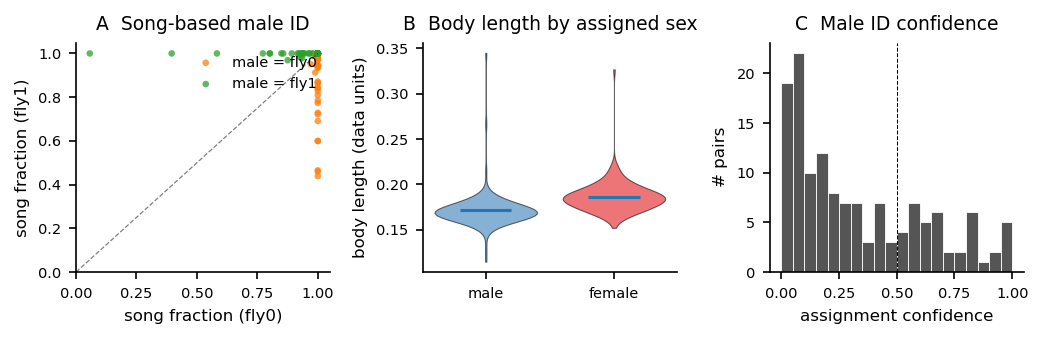

In [ ]:
# --- Figure 1: Male/female identification ---
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.3))

# Panel A plots the raw tracker-slot song fractions and colours by which
# tracker slot was assigned male (pre-swap). The rest of the notebook uses
# the post-swap convention where slot-0 is always the male.
sf0 = df['tracker_song_fraction_fly0'].values
sf1 = df['tracker_song_fraction_fly1'].values
male_is_fly0 = (df['tracker_male_id'] == 'fly0').values

# Panel A — song-fraction scatter
ax = axes[0]
ax.scatter(sf0[male_is_fly0],  sf1[male_is_fly0],  s=10,
           c=FLY_COLORS['fly0'], alpha=0.75, label='male = fly0',
           edgecolor='none')
ax.scatter(sf0[~male_is_fly0], sf1[~male_is_fly0], s=10,
           c=FLY_COLORS['fly1'], alpha=0.75, label='male = fly1',
           edgecolor='none')
ax.plot([0, 1], [0, 1], '--', color='k', lw=0.6, alpha=0.5)
ax.set_xlim(0, max(0.05, float(np.nanmax(sf0)) * 1.05))
ax.set_ylim(0, max(0.05, float(np.nanmax(sf1)) * 1.05))
ax.set_xlabel('song fraction (fly0)')
ax.set_ylabel('song fraction (fly1)')
ax.set_title('A  Song-based male ID')
ax.legend(frameon=False, loc='upper right')

# Panel B — body length by assigned sex
ax = axes[1]
bl_m = df['body_length_male'].values
bl_f = df['body_length_female'].values
bl_m = bl_m[np.isfinite(bl_m)]
bl_f = bl_f[np.isfinite(bl_f)]
parts = ax.violinplot([bl_m, bl_f], positions=[0, 1], widths=0.8,
                      showmeans=True, showextrema=False)
for pc, col in zip(parts['bodies'], ['#377eb8', '#e41a1c']):
    pc.set_facecolor(col); pc.set_alpha(0.6); pc.set_edgecolor('k'); pc.set_linewidth(0.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['male', 'female'])
ax.set_ylabel('body length (data units)')
ax.set_title('B  Body length by assigned sex')

# Panel C — confidence histogram
ax = axes[2]
ax.hist(df['confidence'].values, bins=np.linspace(0, 1, 21),
        color='#555555', edgecolor='white', linewidth=0.4)
ax.axvline(0.5, color='k', lw=0.5, ls='--')
ax.set_xlabel('assignment confidence')
ax.set_ylabel('# pairs')
ax.set_title('C  Male ID confidence')

plt.tight_layout()
out = FIG_DIR / 'fig1_male_female_id.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


example pair_idx=65  keys=bout_130/bout_131  T=1712 (2.140s)  male=fly0
saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig2_song_example_pair065_f120-1200.pdf


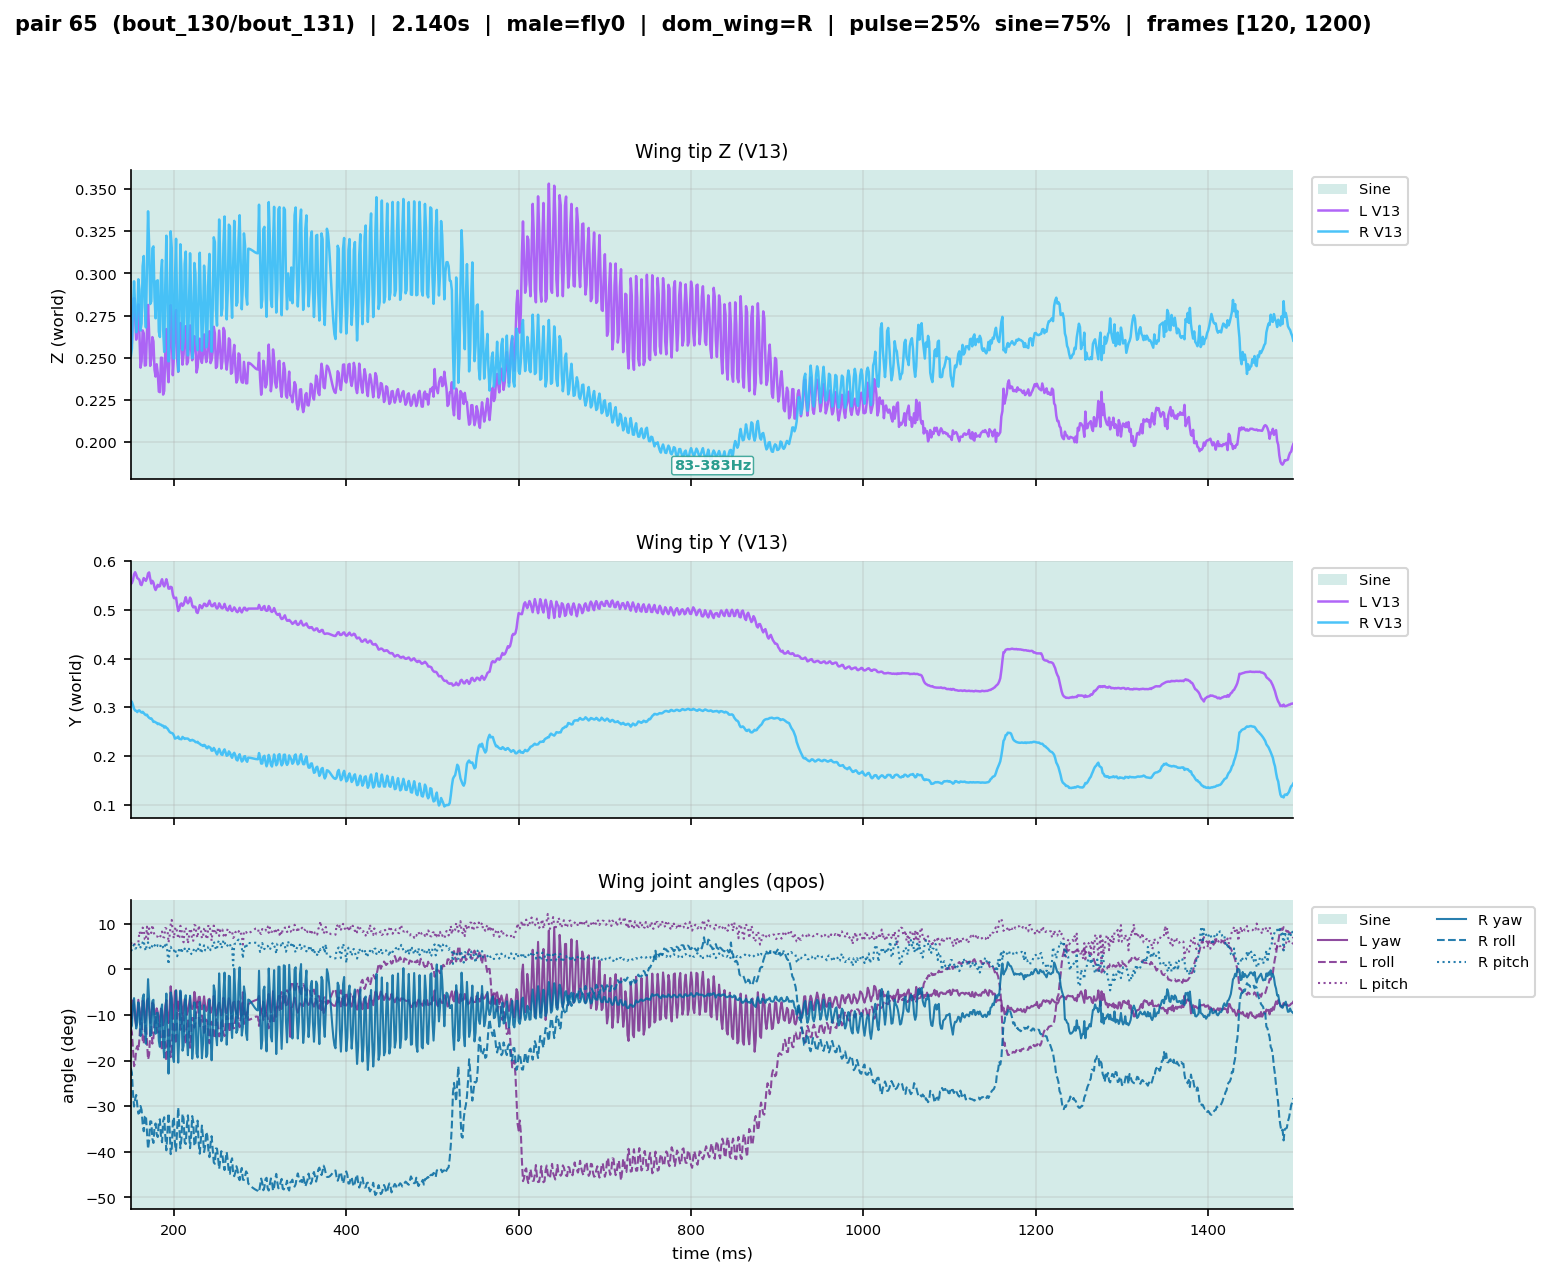

In [ ]:
# --- Figure 2: Song classification example bout (rich 3-panel both-wings view) ---
# Pick a specific pair to visualise. Default is pair 88 (bout_176/bout_177):
#   long sine passage 0.0-0.464s, followed by alternating pulse bursts.
# Set EXAMPLE_IDX=None to auto-pick the bout with the most pulse+sine content.
EXAMPLE_IDX = 65 # 73

# Optional sub-range (in frames, bout-relative) to zoom into a clip of
# the example bout. Inherited by Figure 3 below. None = full bout.
# When trimmed, plotted arrays are sliced so y-axes auto-scale to the
# in-range data only (extreme values outside the range are dropped).
START_FRAME = (150/1000) * 800  # inclusive
END_FRAME   = (1500/1000) * 800  # exclusive; None → render to end of bout

if EXAMPLE_IDX is None:
    example_idx = int((df['frac_pulse'] + df['frac_sine']).idxmax())
else:
    example_idx = int(EXAMPLE_IDX)
ex = results[example_idx]
print(f'example pair_idx={example_idx}  keys={ex["key0"]}/{ex["key1"]}  '
      f'T={ex["T"]} ({ex["T"]/song_cfg.fs:.3f}s)  male={ex["sex"]["male_id"]}')

fs = song_cfg.fs
male_song = ex['song0'] if ex['sex']['male_id'] == 'fly0' else ex['song1']

# ----- plotting helpers (local — not exported) ----------------------------
_SEG_COLORS = {
    'pulse':  '#E76F5133',
    'sine':   '#2A9D8F33',
    'waggle': '#E9C46A33',
    'quiet':  '#cccccc11',
}
_SEG_EDGE_COLORS = {
    'pulse':  '#E76F51',
    'sine':   '#2A9D8F',
    'waggle': '#E9C46A',
    'quiet':  '#999999',
}
_WING_COLORS = {
    'WingL_V12': '#7B2D8E', 'WingL_V13': '#A855F7',
    'WingR_V12': '#0369A1', 'WingR_V13': '#38BDF8',
}


def _add_segment_shading(ax, segments, fs, hatch=None, side_tag=None,
                         seen_labels=None, frame_range=None):
    if seen_labels is None:
        seen_labels = set()
    for seg in segments:
        stype = seg['type']
        if stype == 'quiet':
            continue
        # Clip to the visible frame range if provided; drop segments that
        # fall entirely outside so they don't pollute the legend.
        if frame_range is not None:
            lo, hi = frame_range
            if seg['end'] <= lo or seg['start'] >= hi:
                continue
            seg_start = max(seg['start'], lo)
            seg_end   = min(seg['end'],   hi)
        else:
            seg_start = seg['start']
            seg_end   = seg['end']
        s_ms = seg_start / fs * 1000.0
        e_ms = seg_end   / fs * 1000.0
        color = _SEG_COLORS.get(stype, '#cccccc33')
        label_key = f'{stype}_{side_tag}'
        if label_key in seen_labels:
            label = None
        else:
            label = f'{stype.capitalize()} {side_tag}' if side_tag else stype.capitalize()
            seen_labels.add(label_key)
        ax.axvspan(s_ms, e_ms, facecolor=color, zorder=0, label=label,
                   hatch=hatch, edgecolor=_SEG_EDGE_COLORS.get(stype),
                   linewidth=0)


def _add_segment_freq_annotations(ax, segments, window_features, fs,
                                  frame_range=None):
    wc = window_features.get('window_centers')
    pf = window_features.get('peak_freq')
    if wc is None or pf is None or len(wc) == 0:
        return
    wc = np.asarray(wc); pf = np.asarray(pf)
    for seg in segments:
        stype = seg['type']
        if stype == 'quiet':
            continue
        s, e = seg['start'], seg['end']
        if frame_range is not None:
            lo, hi = frame_range
            if e <= lo or s >= hi:
                continue
            s = max(s, lo); e = min(e, hi)
        in_seg = (wc >= s) & (wc <= e)
        if in_seg.sum() == 0:
            continue
        seg_freqs = pf[in_seg]
        median_f = float(np.nanmedian(seg_freqs))
        min_f = float(np.nanmin(seg_freqs))
        max_f = float(np.nanmax(seg_freqs))
        mid_ms = (s + e) / 2.0 / fs * 1000.0
        edge_color = _SEG_EDGE_COLORS.get(stype, '#999999')
        freq_str = f'{median_f:.0f}Hz' if min_f == max_f else f'{min_f:.0f}-{max_f:.0f}Hz'
        ax.annotate(
            freq_str,
            xy=(mid_ms, 0.02), xycoords=('data', 'axes fraction'),
            fontsize=7, color=edge_color, fontweight='bold',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=edge_color,
                      alpha=0.85, lw=0.7),
        )


def _shade_song(ax, result, fs, seen, frame_range=None):
    # L and R carry identical labels (bilateral pulse mask overwrites both),
    # so a single shading pass is enough — using L's segments.
    _add_segment_shading(ax, result['sides']['L']['segments'], fs=fs,
                         hatch=None, side_tag=None, seen_labels=seen,
                         frame_range=frame_range)


# ----- figure --------------------------------------------------------------
T = male_song['summary']['n_frames']
t_ms_full = np.arange(T) / fs * 1000.0

# Resolve optional sub-range (bout-relative frame indices).
_sf = 0 if START_FRAME is None else max(0, int(START_FRAME))
_ef = T if END_FRAME   is None else min(T, int(END_FRAME))
if _ef <= _sf:
    raise ValueError(f'END_FRAME ({END_FRAME}) must be greater than START_FRAME ({START_FRAME})')
_trimmed = not (_sf == 0 and _ef == T)
_frame_range = (_sf, _ef) if _trimmed else None
clip_tag = f'_f{_sf}-{_ef}' if _trimmed else ''

# Sliced time axis (absolute, in ms) — plots use this so y-autoscale
# only sees the in-range samples.
t_ms = t_ms_full[_sf:_ef]

dom = male_song['dominant_wing']
dom_side = male_song['sides'][dom]
wf = dom_side['window_features']
s = dom_side['summary']

mode_parts = []
for k, lab in (('frac_pulse', 'pulse'), ('frac_sine', 'sine'),
               ('frac_waggle', 'waggle'), ('frac_quiet', 'quiet')):
    v = s.get(k, 0.0)
    if v > 0:
        mode_parts.append(f'{lab}={100*v:.0f}%')
mode_str = '  '.join(mode_parts)

# Build rows dynamically: always show Z and Y panels; show qpos panel only
# if joint angles are available for this bout.
joints = male_song.get('joints')
nrows = 3 if joints is not None else 2
fig, axes = plt.subplots(
    nrows, 1, figsize=(10.0, 3.0 * nrows), sharex=True,
    gridspec_kw={'height_ratios': [1.2, 1.0] + ([1.2] if nrows == 3 else []),
                 'hspace': 0.28},
)
if nrows == 1:
    axes = [axes]
_range_str = f'  |  frames [{_sf}, {_ef})' if _trimmed else ''
fig.suptitle(
    f'pair {example_idx}  ({ex["key0"]}/{ex["key1"]})  |  '
    f'{male_song["summary"]["duration_s"]:.3f}s  |  male={ex["sex"]["male_id"]}  |  '
    f'dom_wing={dom}  |  {mode_str}{_range_str}',
    fontsize=10, fontweight='bold', y=0.995,
)

wd = male_song['wing_data']

# ===== PANEL 1: Wing Tip Z (V13, both wings overlaid) =====
ax = axes[0]
seen = set()
_shade_song(ax, male_song, fs, seen, frame_range=_frame_range)
ax.plot(t_ms, np.asarray(wd['WingL_V13']['z'])[_sf:_ef],
        color=_WING_COLORS['WingL_V13'], lw=1.2, alpha=0.9, label='L V13')
ax.plot(t_ms, np.asarray(wd['WingR_V13']['z'])[_sf:_ef],
        color=_WING_COLORS['WingR_V13'], lw=1.2, alpha=0.9, label='R V13')
_add_segment_freq_annotations(ax, dom_side['segments'], wf, fs,
                              frame_range=_frame_range)
ax.set_ylabel('Z (world)')
ax.set_title('Wing tip Z (V13)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
ax.grid(True, alpha=0.3)

# ===== PANEL 2: Wing Tip Y (V13, both wings overlaid) =====
ax = axes[1]
seen = set()
_shade_song(ax, male_song, fs, seen, frame_range=_frame_range)
ax.plot(t_ms, np.asarray(wd['WingL_V13']['y'])[_sf:_ef],
        color=_WING_COLORS['WingL_V13'], lw=1.2, alpha=0.9, label='L V13')
ax.plot(t_ms, np.asarray(wd['WingR_V13']['y'])[_sf:_ef],
        color=_WING_COLORS['WingR_V13'], lw=1.2, alpha=0.9, label='R V13')
ax.set_ylabel('Y (world)')
ax.set_title('Wing tip Y (V13)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
ax.grid(True, alpha=0.3)

# ===== PANEL 3 (optional): qpos wing joint angles =====
if joints is not None:
    ax = axes[2]
    seen = set()
    _shade_song(ax, male_song, fs, seen, frame_range=_frame_range)
    joint_styles = [
        ('yaw_L',   '#7B2D8E', '-',  'L yaw'),
        ('roll_L',  '#7B2D8E', '--', 'L roll'),
        ('pitch_L', '#7B2D8E', ':',  'L pitch'),
        ('yaw_R',   '#0369A1', '-',  'R yaw'),
        ('roll_R',  '#0369A1', '--', 'R roll'),
        ('pitch_R', '#0369A1', ':',  'R pitch'),
    ]
    for key, color, ls, label in joint_styles:
        if key in joints:
            ax.plot(t_ms,
                    np.degrees(np.asarray(joints[key]))[_sf:_ef],
                    color=color, ls=ls, lw=1.0, alpha=0.85, label=label)
    ax.set_ylabel('angle (deg)')
    ax.set_title('Wing joint angles (qpos)')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('time (ms)')

# Overlay peak-detector pulse events as vertical dashed lines, filtered
# to the visible frame range so they don't clutter the legend count.
pef_full = np.asarray(wf.get('pulse_event_frames', np.array([], dtype=int)))
if pef_full.size > 0:
    pef = pef_full[(pef_full >= _sf) & (pef_full < _ef)]
    pef_ms = pef / fs * 1000.0
    for _ax in axes:
        for i, xm in enumerate(pef_ms):
            _ax.axvline(xm, color='#E76F51', lw=0.6, alpha=0.55,
                        ls='--', zorder=4,
                        label=(f'pulse events (n={len(pef_ms)})'
                               if i == 0 and _ax is axes[0] else None))
    axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7)

# Tighten x-limits to the trimmed range (redundant after slicing, but
# pins the view if axvspans would otherwise stretch it).
for _ax in axes:
    _ax.set_xlim(t_ms_full[_sf], t_ms_full[min(_ef - 1, T - 1)])

# (tight_layout skipped: external legends use bbox_to_anchor)
# out = FIG_DIR / f'fig2_song_example_pair{example_idx:03d}{clip_tag}.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig3_walking_example_f120-1200.pdf


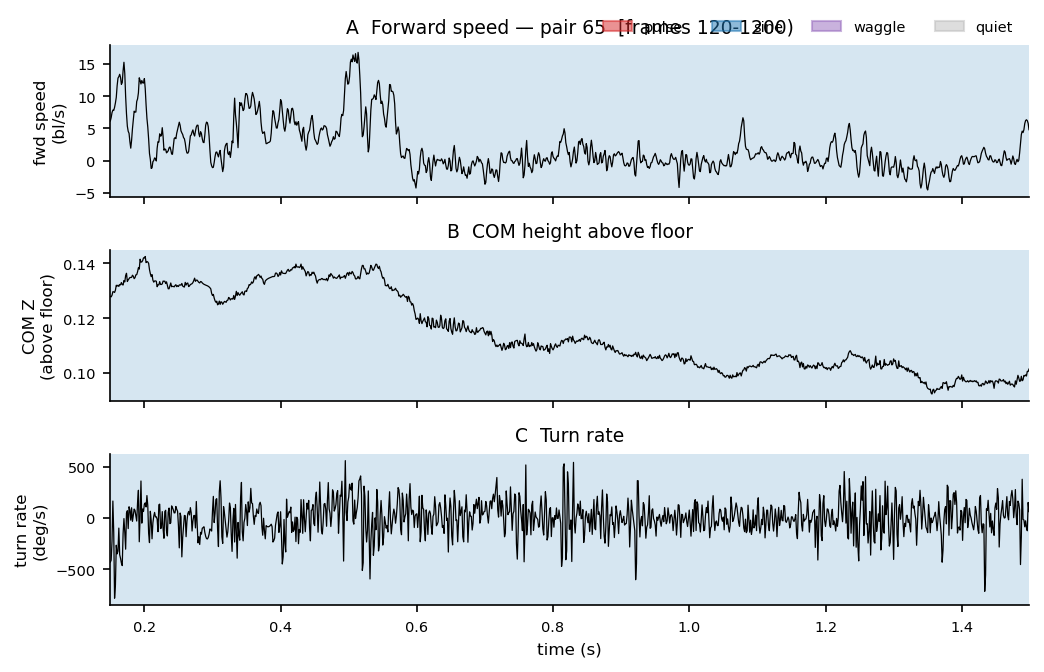

In [8]:
# --- Figure 3: Walking + COM height during song (same example bout) ---
# Inherits START_FRAME / END_FRAME from the Figure 2 cell above.
# Plotted arrays are sliced to the sub-range so y-axes auto-scale only to
# the in-range data.
ex = results[example_idx]
fs = loc_cfg.fs
T = ex['T']
t_full = np.arange(T) / fs
labels_full = np.asarray(ex['male_labels'])

# Resolve optional sub-range (bout-relative frame indices).
_sf = 0 if START_FRAME is None else max(0, int(START_FRAME))
_ef = T if END_FRAME   is None else min(T, int(END_FRAME))
if _ef <= _sf:
    raise ValueError(f'END_FRAME ({END_FRAME}) must be greater than START_FRAME ({START_FRAME})')
_trimmed = not (_sf == 0 and _ef == T)
clip_tag = f'_f{_sf}-{_ef}' if _trimmed else ''

# Slice every plotted quantity to the sub-range.
t      = t_full[_sf:_ef]
labels = labels_full[_sf:_ef]
forward = np.asarray(ex['kin'].get('forward_speed_bl',
                                    ex['kin']['forward_speed']))[_sf:_ef]
turn    = np.asarray(ex['kin']['turn_rate'])[_sf:_ef]
com_z   = np.asarray(ex['com_z'])[_sf:_ef]

def _shade_segments(ax, t, labels):
    """Shade the axes background by per-frame label runs."""
    n = len(labels)
    i = 0
    while i < n:
        j = i
        while j < n and labels[j] == labels[i]:
            j += 1
        ax.axvspan(t[i], t[min(j, n - 1)], color=SONG_COLORS[labels[i]],
                   alpha=0.18, lw=0)
        i = j

fig, axes = plt.subplots(3, 1, figsize=(7.0, 4.5), sharex=True)
_shade_segments(axes[0], t, labels)
axes[0].plot(t, forward, lw=0.6, color='k')
axes[0].set_ylabel('fwd speed\n(bl/s)')
_range_str = f'  [frames {_sf}-{_ef})' if _trimmed else ''
axes[0].set_title(f'A  Forward speed — pair {example_idx}{_range_str}')

_shade_segments(axes[1], t, labels)
axes[1].plot(t, com_z, lw=0.6, color='k')
axes[1].set_ylabel('COM Z\n(above floor)')
axes[1].set_title('B  COM height above floor')

_shade_segments(axes[2], t, labels)
axes[2].plot(t, turn, lw=0.6, color='k')
axes[2].set_ylabel('turn rate\n(deg/s)')
axes[2].set_xlabel('time (s)')
axes[2].set_title('C  Turn rate')

# Explicit xlim to the trimmed window (kept in sync with the slice).
for _ax in axes:
    _ax.set_xlim(t[0], t[-1])

from matplotlib.patches import Patch
handles = [Patch(color=SONG_COLORS[k], label=k, alpha=0.5)
            for k in ('pulse', 'sine', 'waggle', 'quiet')]
fig.legend(handles=handles, loc='upper right', frameon=False,
            bbox_to_anchor=(0.98, 0.99), ncol=4)
plt.tight_layout()

out = FIG_DIR / f'fig3_walking_example{clip_tag}.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


In [9]:
# --- Figure 2 multi-page PDF: one page per pair ---
# Generates fig2_song_all_pairs.pdf — same layout as the single-pair Figure 2
# above, full bout per page, for easy scanning. Reuses the helpers defined in
# the Figure 2 cell (_shade_song, _add_segment_freq_annotations, etc.), so
# that cell must have been run first.
from matplotlib.backends.backend_pdf import PdfPages

_fs_song = song_cfg.fs


def _build_song_figure_for_pair(result):
    """Build the Figure-2 layout for one pair over the full bout. Returns fig."""
    ms = result['song0'] if result['sex']['male_id'] == 'fly0' else result['song1']
    idx = result['pair_idx']

    T_ = ms['summary']['n_frames']
    t_ms_ = np.arange(T_) / _fs_song * 1000.0

    dom_ = ms['dominant_wing']
    dom_side_ = ms['sides'][dom_]
    wf_ = dom_side_['window_features']
    s_ = dom_side_['summary']

    mode_parts_ = []
    for k, lab in (('frac_pulse', 'pulse'), ('frac_sine', 'sine'),
                   ('frac_waggle', 'waggle'), ('frac_quiet', 'quiet')):
        v = s_.get(k, 0.0)
        if v > 0:
            mode_parts_.append(f'{lab}={100*v:.0f}%')
    mode_str_ = '  '.join(mode_parts_)

    joints_ = ms.get('joints')
    nrows_ = 3 if joints_ is not None else 2
    fig_, axes_ = plt.subplots(
        nrows_, 1, figsize=(10.0, 3.0 * nrows_), sharex=True,
        gridspec_kw={'height_ratios': [1.2, 1.0] + ([1.2] if nrows_ == 3 else []),
                     'hspace': 0.28},
    )
    if nrows_ == 1:
        axes_ = [axes_]
    fig_.suptitle(
        f'pair {idx}  ({result["key0"]}/{result["key1"]})  |  '
        f'{ms["summary"]["duration_s"]:.3f}s  |  male={result["sex"]["male_id"]}  |  '
        f'dom_wing={dom_}  |  {mode_str_}',
        fontsize=10, fontweight='bold', y=0.995,
    )

    wd_ = ms['wing_data']

    # Panel 1: Wing tip Z
    ax = axes_[0]
    _shade_song(ax, ms, _fs_song, set())
    ax.plot(t_ms_, np.asarray(wd_['WingL_V13']['z']),
            color=_WING_COLORS['WingL_V13'], lw=1.2, alpha=0.9, label='L V13')
    ax.plot(t_ms_, np.asarray(wd_['WingR_V13']['z']),
            color=_WING_COLORS['WingR_V13'], lw=1.2, alpha=0.9, label='R V13')
    _add_segment_freq_annotations(ax, dom_side_['segments'], wf_, _fs_song)
    ax.set_ylabel('Z (world)')
    ax.set_title('Wing tip Z (V13)')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
    ax.grid(True, alpha=0.3)

    # Panel 2: Wing tip Y
    ax = axes_[1]
    _shade_song(ax, ms, _fs_song, set())
    ax.plot(t_ms_, np.asarray(wd_['WingL_V13']['y']),
            color=_WING_COLORS['WingL_V13'], lw=1.2, alpha=0.9, label='L V13')
    ax.plot(t_ms_, np.asarray(wd_['WingR_V13']['y']),
            color=_WING_COLORS['WingR_V13'], lw=1.2, alpha=0.9, label='R V13')
    ax.set_ylabel('Y (world)')
    ax.set_title('Wing tip Y (V13)')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
    ax.grid(True, alpha=0.3)

    # Panel 3 (optional): qpos wing joint angles
    if joints_ is not None:
        ax = axes_[2]
        _shade_song(ax, ms, _fs_song, set())
        _joint_styles = [
            ('yaw_L',   '#7B2D8E', '-',  'L yaw'),
            ('roll_L',  '#7B2D8E', '--', 'L roll'),
            ('pitch_L', '#7B2D8E', ':',  'L pitch'),
            ('yaw_R',   '#0369A1', '-',  'R yaw'),
            ('roll_R',  '#0369A1', '--', 'R roll'),
            ('pitch_R', '#0369A1', ':',  'R pitch'),
        ]
        for jkey, jcolor, jls, jlabel in _joint_styles:
            if jkey in joints_:
                ax.plot(t_ms_, np.degrees(np.asarray(joints_[jkey])),
                        color=jcolor, ls=jls, lw=1.0, alpha=0.85, label=jlabel)
        ax.set_ylabel('angle (deg)')
        ax.set_title('Wing joint angles (qpos)')
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

    axes_[-1].set_xlabel('time (ms)')

    # Pulse event overlay
    _pef = np.asarray(wf_.get('pulse_event_frames', np.array([], dtype=int)))
    if _pef.size > 0:
        _pef_ms = _pef / _fs_song * 1000.0
        for _ax in axes_:
            for i_, xm_ in enumerate(_pef_ms):
                _ax.axvline(xm_, color='#E76F51', lw=0.6, alpha=0.55,
                            ls='--', zorder=4,
                            label=(f'pulse events (n={len(_pef_ms)})'
                                   if i_ == 0 and _ax is axes_[0] else None))
        axes_[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7)

    return fig_


_out_pdf = FIG_DIR / 'fig2_song_all_pairs.pdf'
_n = len(results)
print(f'writing {_n} pair figures to {_out_pdf}')
with PdfPages(_out_pdf) as _pdf:
    for _i, _r in enumerate(results):
        try:
            _fig = _build_song_figure_for_pair(_r)
            _pdf.savefig(_fig, bbox_inches='tight')
            plt.close(_fig)
        except Exception as _e:
            print(f'  pair {_r.get("pair_idx", _i)}: {type(_e).__name__}: {_e}')
        if (_i + 1) % 25 == 0 or (_i + 1) == _n:
            print(f'  wrote {_i + 1}/{_n}')
print(f'saved {_out_pdf}')


writing 138 pair figures to /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig2_song_all_pairs.pdf
  wrote 25/138
  wrote 50/138
  wrote 75/138
  wrote 100/138
  wrote 125/138
  wrote 138/138
saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig2_song_all_pairs.pdf


saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig4_agg_song_locomotion.pdf


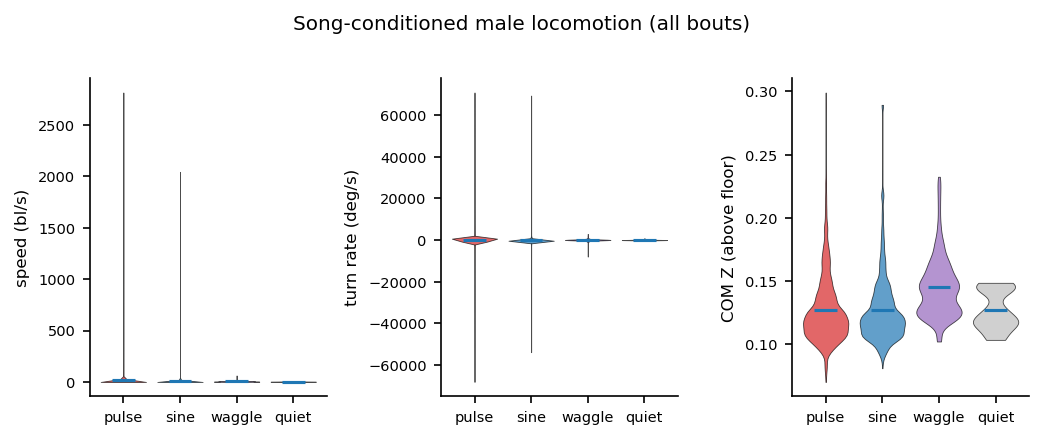

In [10]:
# --- Figure 4: Song-conditioned locomotion across ALL bouts ---
# Concatenate per-frame male metrics across bouts, keeping only frames
# where the male is valid (colocation-filtered already).
agg = defaultdict(lambda: defaultdict(list))  # metric → song → [values]
for r in results:
    valid = np.asarray(r['male_valid'], dtype=bool)
    if not valid.any():
        continue
    labels = np.asarray(r['male_labels'])[valid]
    metric_vals = {
        'speed_bl':  np.asarray(r['kin'].get('speed_bl', r['kin']['speed']))[valid],
        'turn_rate': np.asarray(r['kin']['turn_rate'])[valid],
        'com_z':     np.asarray(r['com_z'])[valid],
    }
    for m, v in metric_vals.items():
        for song in ('pulse', 'sine', 'waggle', 'quiet'):
            sel = (labels == song)
            if not sel.any():
                continue
            vs = v[sel]
            vs = vs[np.isfinite(vs)]
            if vs.size:
                agg[m][song].extend(vs.tolist())

METRIC_LABELS = {
    'speed_bl':  'speed (bl/s)',
    'turn_rate': 'turn rate (deg/s)',
    'com_z':     'COM Z (above floor)',
}
SONG_ORDER = ['pulse', 'sine', 'waggle', 'quiet']

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.8))
for ax, m in zip(axes, ['speed_bl', 'turn_rate', 'com_z']):
    datas = [np.asarray(agg[m].get(s, []), dtype=float) for s in SONG_ORDER]
    datas = [d[np.isfinite(d)] for d in datas]
    has_all = all(d.size > 10 for d in datas)
    if has_all:
        parts = ax.violinplot(datas, positions=range(len(SONG_ORDER)),
                              widths=0.8, showmeans=True, showextrema=False)
        for pc, s in zip(parts['bodies'], SONG_ORDER):
            pc.set_facecolor(SONG_COLORS[s]); pc.set_alpha(0.7)
            pc.set_edgecolor('k'); pc.set_linewidth(0.4)
    else:
        means = [float(np.mean(d)) if d.size else float('nan') for d in datas]
        sems  = [float(np.std(d) / np.sqrt(max(1, d.size))) if d.size else 0.0
                 for d in datas]
        ax.bar(range(len(SONG_ORDER)), means, yerr=sems,
               color=[SONG_COLORS[s] for s in SONG_ORDER],
               edgecolor='k', linewidth=0.4)
    ax.set_xticks(range(len(SONG_ORDER)))
    ax.set_xticklabels(SONG_ORDER, rotation=0)
    ax.set_ylabel(METRIC_LABELS[m])

fig.suptitle('Song-conditioned male locomotion (all bouts)', y=1.02)
plt.tight_layout()
out = FIG_DIR / 'fig4_agg_song_locomotion.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig5_per_bout_stacked.pdf


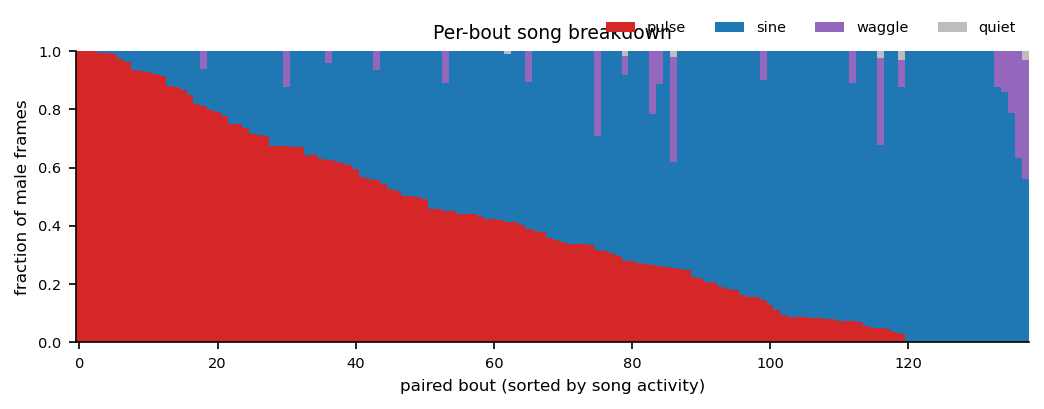

In [11]:
# --- Figure 5: Per-bout song breakdown (stacked bars) ---
df_sorted = df.sort_values(
    by=['frac_pulse', 'frac_sine', 'frac_waggle'], ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.0, 2.8))
x = np.arange(len(df_sorted))
bottom = np.zeros(len(df_sorted))
for song in ('pulse', 'sine', 'waggle', 'quiet'):
    vals = df_sorted[f'frac_{song}'].values
    ax.bar(x, vals, bottom=bottom, color=SONG_COLORS[song],
            width=1.0, edgecolor='none', label=song)
    bottom += vals
ax.set_xlim(-0.5, len(df_sorted) - 0.5)
ax.set_ylim(0, 1.0)
ax.set_xlabel('paired bout (sorted by song activity)')
ax.set_ylabel('fraction of male frames')
ax.set_title('Per-bout song breakdown')
ax.legend(frameon=False, loc='upper right', ncol=4, bbox_to_anchor=(1.0, 1.15))
plt.tight_layout()

out = FIG_DIR / 'fig5_per_bout_stacked.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


fig6: pooled 836 pulses from 113 pairs, window 21 samples
fig6: component_symmetry=[-0.16517077 -0.38393053]  label_map={0: 'Pslow', 1: 'Pfast'}
fig6: Pslow=525, Pfast=311


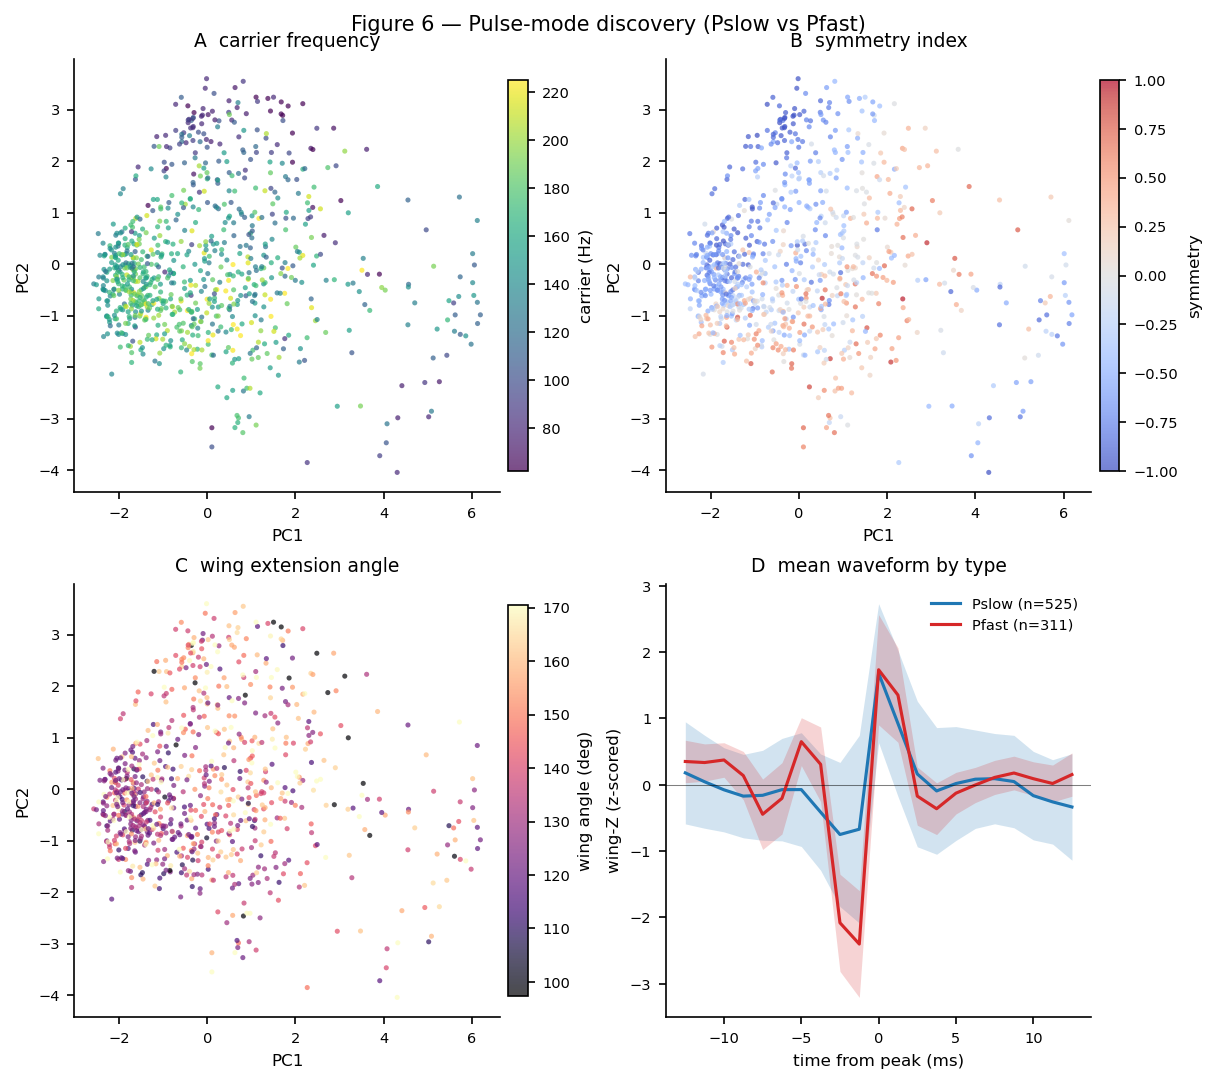

fig6 → /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig6_pulse_mode_discovery.png


In [12]:
# --- Figure 6: Pulse-mode discovery (Pslow vs Pfast, Clemens 2018 analog) ---
# Pools every per-pulse waveform across pairs (male dominant wing), runs
# PCA + 2-component GMM, assigns Pslow/Pfast by cluster mean symmetry,
# and renders a 4-panel composite:
#   A  PCA scatter colored by carrier frequency (spectral center-of-mass)
#   B  PCA scatter colored by symmetry index
#   C  PCA scatter colored by wing extension angle
#   D  Mean ± std waveform per pulse type
from utils.pulse_types import PulseTypeConfig, fit_pulse_type_model, classify_pulses

def _male_pulse_side(r):
    male_song = r['song0'] if r['sex']['male_id'] == 'fly0' else r['song1']
    dw = str(male_song.get('dominant_wing', 'L')).upper()
    side_key = 'L' if dw.startswith('L') else 'R'
    return male_song, side_key


waves_list, sym_list, hz_list, ang_list = [], [], [], []
pair_idx_list, frame_list = [], []
for r in results:
    male_song, side_key = _male_pulse_side(r)
    pf = male_song['sides'][side_key].get('pulse_features')
    if pf is None or pf['waveforms'].shape[0] == 0:
        continue
    w = pf['waveforms']
    waves_list.append(w)
    sym_list.append(pf['symmetry'])
    hz_list.append(pf['carrier_hz'])
    wa = pf['wing_angle']
    if wa is None:
        wa = np.full(w.shape[0], np.nan)
    ang_list.append(np.asarray(wa))
    pair_idx_list.append(np.full(w.shape[0], r.get('pair_idx', -1), dtype=int))
    frame_list.append(np.asarray(pf['peak_frames'], dtype=int))

if not waves_list:
    print('fig6: no pulses in results; skipping')
else:
    W = np.vstack(waves_list)
    sym = np.concatenate(sym_list)
    hz  = np.concatenate(hz_list)
    ang = np.concatenate(ang_list)
    pair_vec = np.concatenate(pair_idx_list)
    print(f'fig6: pooled {W.shape[0]} pulses from {len(waves_list)} pairs, '
          f'window {W.shape[1]} samples')

    pt_cfg = PulseTypeConfig(n_pca=6)
    model = fit_pulse_type_model(W, sym, pt_cfg)
    labels = classify_pulses(W, model)
    print(f'fig6: component_symmetry={model.component_symmetry}  '
          f'label_map={model.label_map}')
    print(f'fig6: Pslow={int((labels=="Pslow").sum())}, '
          f'Pfast={int((labels=="Pfast").sum())}')

    # 2D PCA for scatter (fit fresh on 2 components so we don't discard
    # the GMM's higher-dim model — this is a display projection only).
    from sklearn.decomposition import PCA as _PCA
    pca2 = _PCA(n_components=2, random_state=0).fit(W)
    X2 = pca2.transform(W)

    fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.0), constrained_layout=True)
    axA, axB, axC, axD = axes.flat

    def _scatter(ax, colors, cmap, label, vmin=None, vmax=None):
        sc = ax.scatter(
            X2[:, 0], X2[:, 1],
            c=colors, s=6, cmap=cmap, alpha=0.7, linewidths=0,
            vmin=vmin, vmax=vmax,
        )
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
        cb.set_label(label)

    _scatter(axA, hz, 'viridis', 'carrier (Hz)',
             vmin=np.nanpercentile(hz, 2),
             vmax=np.nanpercentile(hz, 98))
    axA.set_title('A  carrier frequency')

    _scatter(axB, sym, 'coolwarm', 'symmetry',
             vmin=-1.0, vmax=1.0)
    axB.set_title('B  symmetry index')

    ang_plot = np.where(np.isfinite(ang), ang, np.nan)
    _scatter(axC, ang_plot, 'magma', 'wing angle (deg)',
             vmin=np.nanpercentile(ang_plot, 2)
                  if np.isfinite(ang_plot).any() else 0,
             vmax=np.nanpercentile(ang_plot, 98)
                  if np.isfinite(ang_plot).any() else 90)
    axC.set_title('C  wing extension angle')

    # Panel D: mean ± std waveform per type
    fs_axis = np.arange(W.shape[1]) - W.shape[1] // 2
    fs_ms = fs_axis * 1000.0 / song_cfg.fs
    type_colors = {'Pslow': '#1f77b4', 'Pfast': '#d62728'}
    for t in ('Pslow', 'Pfast'):
        sel = labels == t
        if not sel.any():
            continue
        m = W[sel].mean(axis=0)
        s = W[sel].std(axis=0)
        axD.plot(fs_ms, m, color=type_colors[t], lw=1.5,
                 label=f'{t} (n={int(sel.sum())})')
        axD.fill_between(fs_ms, m - s, m + s,
                          color=type_colors[t], alpha=0.2, linewidth=0)
    axD.axhline(0, color='k', lw=0.5, alpha=0.5)
    axD.set_xlabel('time from peak (ms)')
    axD.set_ylabel('wing-Z (z-scored)')
    axD.set_title('D  mean waveform by type')
    axD.legend(loc='upper right', frameon=False)

    fig.suptitle('Figure 6 — Pulse-mode discovery (Pslow vs Pfast)',
                 fontsize=10, y=1.01)
    out = FIG_DIR / 'fig6_pulse_mode_discovery.png'
    fig.savefig(out, dpi=200)
    plt.show()
    print(f'fig6 → {out}')

    # Stash for Fig 7 / Fig 8 cells.
    FIG6_CTX = {
        'W': W,
        'sym': sym,
        'hz': hz,
        'ang': ang,
        'pair_idx': pair_vec,
        'frames': np.concatenate(frame_list),
        'labels': labels,
        'model': model,
    }


fig7: 836/836 pulses with distance (unit: body lengths)


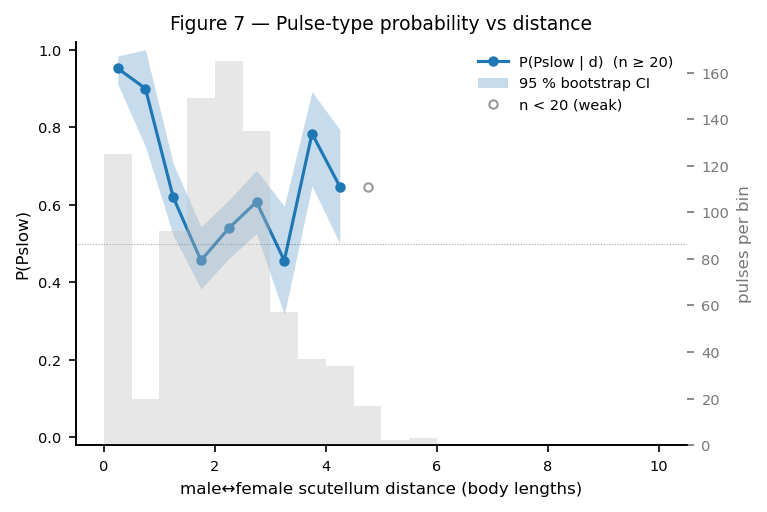

fig7 → /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig7_pslow_fraction_vs_distance.png


In [13]:
# --- Figure 7: P(Pslow | male↔female distance), Clemens Fig 3D analog ---
# Per-pulse distance between male and female scutellum at the pulse
# frame, binned by body-length-normalised distance.
try:
    ctx = FIG6_CTX
except NameError:
    print('fig7: FIG6_CTX missing (run Fig 6 first); skipping')
    ctx = None

if ctx is not None:
    scut_i = kp_names.index('Scutellum')

    # Per-pulse distance lookup using results list + in-memory data.
    # pair_idx → (male_key, female_key, body_length)
    pair_info = {}
    for r in results:
        mid = r['sex']['male_id']
        male_key = r['key0'] if mid == 'fly0' else r['key1']
        fem_key  = r['key1'] if mid == 'fly0' else r['key0']
        bl = r['sex'].get('body_length_male', np.nan)
        pair_info[r.get('pair_idx', -1)] = (male_key, fem_key, float(bl))

    # Cache per-pair per-frame distance traces (avoid re-reading h5
    # for every pulse).
    dist_cache = {}
    def _get_dist(pi):
        if pi in dist_cache:
            return dist_cache[pi]
        male_key, fem_key, bl = pair_info[pi]
        mk = np.asarray(data[male_key]['kp_data'])
        fk = np.asarray(data[fem_key]['kp_data'])
        if mk.ndim == 2:
            mk = mk.reshape(mk.shape[0], -1, 3)
        if fk.ndim == 2:
            fk = fk.reshape(fk.shape[0], -1, 3)
        T_ = min(len(mk), len(fk))
        d = np.linalg.norm(mk[:T_, scut_i] - fk[:T_, scut_i], axis=1)
        if np.isfinite(bl) and bl > 0:
            d = d / bl
            unit = 'body lengths'
        else:
            unit = 'raw units'
        dist_cache[pi] = (d, unit)
        return dist_cache[pi]

    per_pulse_d = np.full(ctx['frames'].shape[0], np.nan)
    unit = 'raw units'
    for i, (pi, f) in enumerate(zip(ctx['pair_idx'], ctx['frames'])):
        d, unit = _get_dist(int(pi))
        if 0 <= f < len(d):
            per_pulse_d[i] = d[f]
    finite = np.isfinite(per_pulse_d)
    print(f'fig7: {finite.sum()}/{len(per_pulse_d)} pulses with distance '
          f'(unit: {unit})')

    # Bin by distance: choose bin edges adaptively from the data range
    if unit == 'body lengths':
        edges = np.arange(0.0, 10.01, 0.5)
    else:
        # raw units — use per-data percentiles
        lo = float(np.nanpercentile(per_pulse_d, 1))
        hi = float(np.nanpercentile(per_pulse_d, 99))
        edges = np.linspace(lo, hi, 16)
    centers = 0.5 * (edges[:-1] + edges[1:])

    labels = ctx['labels']
    rng = np.random.default_rng(0)
    n_boot = 1000

    frac_mean = np.full(len(centers), np.nan)
    frac_lo   = np.full(len(centers), np.nan)
    frac_hi   = np.full(len(centers), np.nan)
    n_in_bin  = np.zeros(len(centers), dtype=int)
    for bi in range(len(centers)):
        sel = finite & (per_pulse_d >= edges[bi]) & (per_pulse_d < edges[bi + 1])
        n_in_bin[bi] = int(sel.sum())
        if n_in_bin[bi] < 5:
            continue
        y = (labels[sel] == 'Pslow').astype(float)
        frac_mean[bi] = float(y.mean())
        idx = rng.integers(0, y.size, size=(n_boot, y.size))
        boots = y[idx].mean(axis=1)
        frac_lo[bi] = float(np.percentile(boots, 2.5))
        frac_hi[bi] = float(np.percentile(boots, 97.5))

    fig, ax = plt.subplots(figsize=(5.0, 3.3), constrained_layout=True)
    good = np.isfinite(frac_mean)
    weak = good & (n_in_bin < 20)
    strong = good & (n_in_bin >= 20)
    ax.plot(centers[strong], frac_mean[strong], '-o', color='#1f77b4',
            lw=1.5, ms=4, label='P(Pslow | d)  (n ≥ 20)')
    ax.fill_between(centers[strong], frac_lo[strong], frac_hi[strong],
                    color='#1f77b4', alpha=0.25, linewidth=0,
                    label='95 % bootstrap CI')
    if weak.any():
        ax.plot(centers[weak], frac_mean[weak], 'o', mfc='none',
                mec='#999999', mew=1.0, ms=4, label='n < 20 (weak)')

    ax.axhline(0.5, color='k', lw=0.5, alpha=0.4, linestyle=':')
    ax.set_xlabel(f'male↔female scutellum distance ({unit})')
    ax.set_ylabel('P(Pslow)')
    ax.set_ylim(-0.02, 1.02)
    ax.set_title('Figure 7 — Pulse-type probability vs distance')
    ax.legend(loc='best', frameon=False)

    ax2 = ax.twinx()
    ax2.bar(centers, n_in_bin, width=np.diff(edges),
            color='#bdbdbd', alpha=0.35, align='center',
            edgecolor='none', zorder=0)
    ax2.set_ylabel('pulses per bin', color='#777777')
    ax2.spines['top'].set_visible(False)
    ax2.tick_params(colors='#777777')

    out = FIG_DIR / 'fig7_pslow_fraction_vs_distance.png'
    fig.savefig(out, dpi=200)
    plt.show()
    print(f'fig7 → {out}')


fig8: 723 IPIs total  (Pslow-led 441, Pfast-led 282)


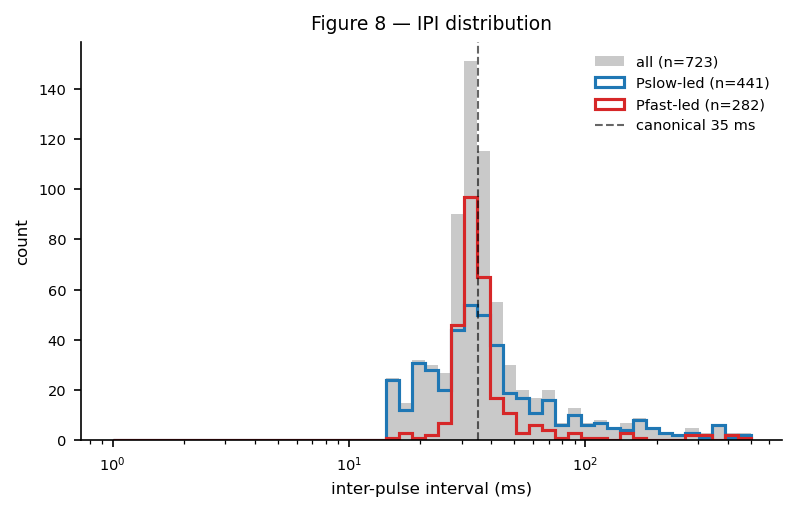

fig8 → /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig8_ipi_histogram.png


In [14]:
# --- Figure 8: IPI (inter-pulse interval) histogram ---
# Pools inter-pulse intervals across all pair males' dominant wing, and
# overlays per-type IPIs using the Fig-6 labels. The canonical
# D. melanogaster IPI is ~35 ms.
try:
    ctx = FIG6_CTX
except NameError:
    print('fig8: FIG6_CTX missing (run Fig 6 first); skipping')
    ctx = None

if ctx is not None:
    # Collect per-pair male IPIs (all pulses, not split yet).
    ipi_all = []
    ipi_slow = []
    ipi_fast = []

    # We have labels in ctx indexed by (pair, frame). For per-train IPIs we
    # need consecutive pulses from the same pair — ctx['frames'] is the
    # concatenation of per-pair peak_frames in pair order, so we can split
    # by pair_idx.
    pair_vec = ctx['pair_idx']
    frames   = ctx['frames']
    labels   = ctx['labels']
    fs_ = song_cfg.fs
    unique_pairs = np.unique(pair_vec)
    for pi in unique_pairs:
        sel = pair_vec == pi
        fs_this = frames[sel]
        lbl_this = labels[sel]
        order = np.argsort(fs_this)
        fs_this = fs_this[order]
        lbl_this = lbl_this[order]
        if fs_this.size < 2:
            continue
        ipi = np.diff(fs_this) * 1000.0 / fs_
        ipi_all.append(ipi)
        # Label an IPI by the label of its *leading* pulse.
        for j, iv in enumerate(ipi):
            if lbl_this[j] == 'Pslow':
                ipi_slow.append(iv)
            else:
                ipi_fast.append(iv)

    ipi_all  = np.concatenate(ipi_all)  if ipi_all  else np.array([])
    ipi_slow = np.asarray(ipi_slow, dtype=float)
    ipi_fast = np.asarray(ipi_fast, dtype=float)
    print(f'fig8: {ipi_all.size} IPIs total  '
          f'(Pslow-led {ipi_slow.size}, Pfast-led {ipi_fast.size})')

    fig, ax = plt.subplots(figsize=(5.2, 3.3), constrained_layout=True)
    bins = np.logspace(np.log10(1), np.log10(500), 50)
    if ipi_all.size:
        ax.hist(ipi_all, bins=bins, color='#666666', alpha=0.35,
                label=f'all (n={ipi_all.size})', edgecolor='none')
    if ipi_slow.size:
        ax.hist(ipi_slow, bins=bins, histtype='step',
                color='#1f77b4', lw=1.5,
                label=f'Pslow-led (n={ipi_slow.size})')
    if ipi_fast.size:
        ax.hist(ipi_fast, bins=bins, histtype='step',
                color='#d62728', lw=1.5,
                label=f'Pfast-led (n={ipi_fast.size})')
    ax.axvline(35, color='k', lw=1.0, linestyle='--', alpha=0.6,
               label='canonical 35 ms')
    ax.set_xscale('log')
    ax.set_xlabel('inter-pulse interval (ms)')
    ax.set_ylabel('count')
    ax.set_title('Figure 8 — IPI distribution')
    ax.legend(loc='best', frameon=False)
    out = FIG_DIR / 'fig8_ipi_histogram.png'
    fig.savefig(out, dpi=200)
    plt.show()
    print(f'fig8 → {out}')


In [15]:
# --- Export per-bout results table ---
csv_path = FIG_DIR / 'per_bout_results.csv'
df.to_csv(csv_path, index=False)
print(f'wrote {csv_path}  ({len(df)} rows, {len(df.columns)} cols)')


wrote /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/per_bout_results.csv  (138 rows, 57 cols)


In [16]:
# --- Text summary ---
n_pairs = len(df)
n_conf  = int((df['confidence'] >= 0.5).sum())
n_song  = int((df['criterion'] == 'song_fraction').sum())
n_disag = int(df['disagree_bodylen'].sum())

print(f'pairs processed        : {n_pairs}')
print(f'  male-ID confidence ≥0.5 : {n_conf}  ({100*n_conf/n_pairs:.1f}%)')
print(f'  song-based male ID      : {n_song}  ({100*n_song/n_pairs:.1f}%)')
print(f'  body-length disagreement: {n_disag}  ({100*n_disag/max(1,n_song):.1f}% of song-based calls)')
print()
print('median song fractions (male):')
for s in ('pulse', 'sine', 'waggle', 'quiet'):
    print(f'  {s:7s}: {df[f"frac_{s}"].median():.3f}')
print()
print('median locomotion (male):')
print(f'  mean speed      : {df["mean_speed_bl"].median():.3f} bl/s')
print(f'  mean COM Z      : {df["mean_com_z"].median():.3f}')
print(f'  walking fraction: {df["walking_fraction"].median():.3f}')


pairs processed        : 138
  male-ID confidence ≥0.5 : 40  (29.0%)
  song-based male ID      : 50  (36.2%)
  body-length disagreement: 7  (14.0% of song-based calls)

median song fractions (male):
  pulse  : 0.355
  sine   : 0.591
  waggle : 0.000
  quiet  : 0.000

median locomotion (male):
  mean speed      : 7.827 bl/s
  mean COM Z      : 0.124
  walking fraction: 1.000


## Figure captions

**Figure 1 — Male/female identification.** (A) Scatter of song fractions for fly0 vs fly1 in every paired bout, colored by which fly was assigned male. Points far from the diagonal reflect confident, song-driven assignments. (B) Body length distribution for the assigned male and female across all pairs (sanity check: males should be the smaller fly). (C) Histogram of male-ID confidence; the vertical dashed line marks the default threshold used for downstream filtering.

**Figure 2 — Song classification (example bout).** (A) Dominant-wing tip Z trace over time for the assigned male. (B) Spectrogram of the same trace with horizontal guides at the waggle / sine / pulse frequency band edges used by the classifier. (C) Per-frame label strip (pulse / sine / waggle / quiet).

**Figure 3 — Walking and COM height during song (same bout).** (A) Male forward speed in body-lengths per second, shaded by the per-frame song label. (B) Male COM Z above the per-bout estimated floor plane. (C) Male turn rate in deg/s.

**Figure 4 — Song-conditioned locomotion (aggregate).** Violin plots (or bars + SEM when sample sizes are small) of male walking speed, turn rate, and COM height, split by song label, concatenated across all bouts with a confident male assignment.

**Figure 5 — Per-bout song breakdown.** Stacked bars showing the fraction of male frames labeled pulse / sine / waggle / quiet for every paired bout, sorted by pulse+sine content. Quiet bouts sit on the right.
